In [2]:
!pip install librosa

In [3]:
from google.colab import files
uploaded = files.upload()

Saving LJ050-0275.wav to LJ050-0275.wav


In [4]:
# Get uploaded file name
file_path = list(uploaded.keys())[0]

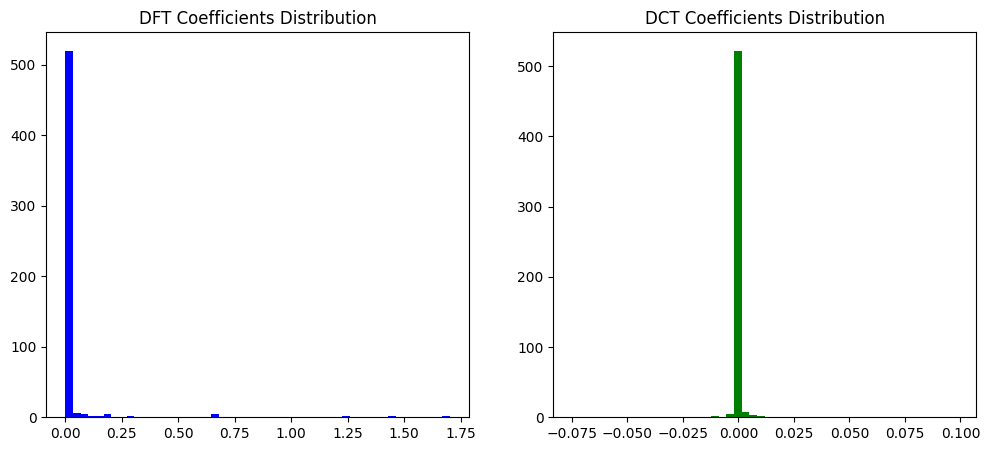

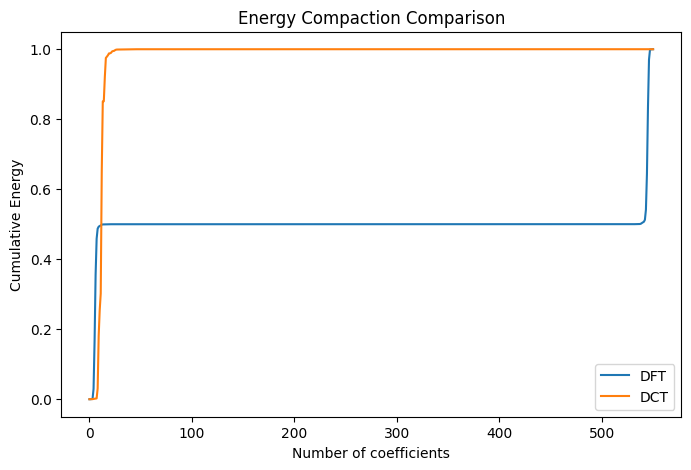

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.fft import fft
from scipy.fftpack import dct

# -----------------------------
# 1. Load speech signal
# -----------------------------
file_path = list(uploaded.keys())[0]
signal, sr = librosa.load(file_path, sr=None)

# -----------------------------
# 2. Frame extraction (25 ms)
# -----------------------------
frame_size = int(0.025 * sr)   # 25 ms
frame = signal[0:frame_size]

# -----------------------------
# 3. Apply Hamming window
# -----------------------------
hamming_window = np.hamming(frame_size)
windowed_frame = frame * hamming_window

# -----------------------------
# 4. Compute DFT and DCT
# -----------------------------
dft_coeff = np.abs(fft(windowed_frame))
dct_coeff = dct(windowed_frame, norm='ortho')

# -----------------------------
# 5. Energy computation
# -----------------------------
dft_energy = dft_coeff**2
dct_energy = dct_coeff**2

# cumulative energy
dft_cum_energy = np.cumsum(dft_energy) / np.sum(dft_energy)
dct_cum_energy = np.cumsum(dct_energy) / np.sum(dct_energy)

# -----------------------------
# 6. Plot histogram
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(dft_coeff, bins=50, color='blue')
plt.title("DFT Coefficients Distribution")

plt.subplot(1,2,2)
plt.hist(dct_coeff, bins=50, color='green')
plt.title("DCT Coefficients Distribution")

plt.show()

# -----------------------------
# 7. Plot energy compaction
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(dft_cum_energy, label="DFT")
plt.plot(dct_cum_energy, label="DCT")
plt.xlabel("Number of coefficients")
plt.ylabel("Cumulative Energy")
plt.title("Energy Compaction Comparison")
plt.legend()
plt.show()

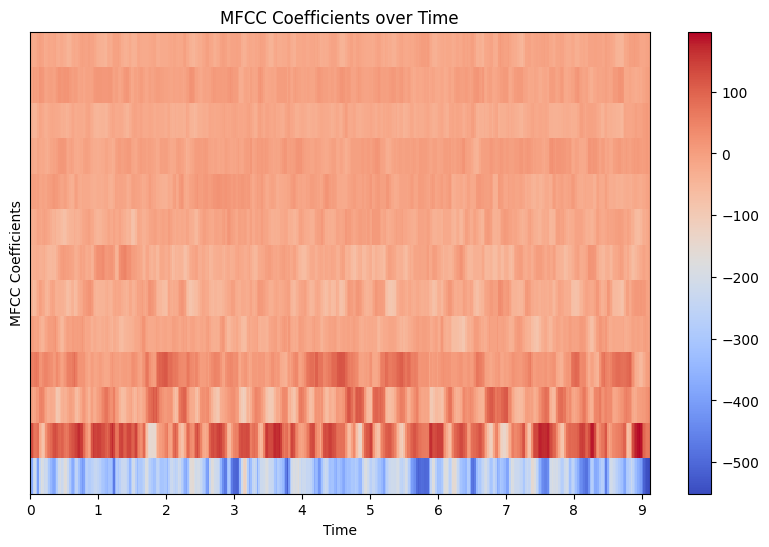

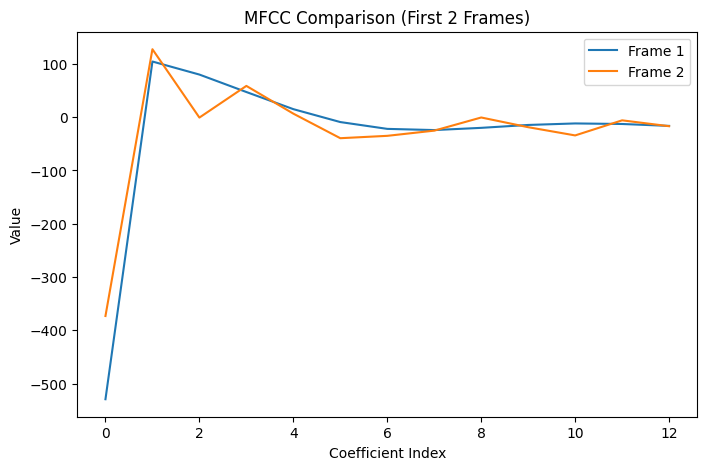

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Load signal
# -----------------------------
file_path = list(uploaded.keys())[0]
signal, sr = librosa.load(file_path, sr=None)

# -----------------------------
# 2. Extract MFCC
# -----------------------------
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

# -----------------------------
# 3. Plot MFCC over time
# -----------------------------
plt.figure(figsize=(10,6))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC Coefficients over Time")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time")
plt.show()

# -----------------------------
# 4. Plot first few MFCCs for first 2 frames
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(mfccs[:,0], label="Frame 1")
plt.plot(mfccs[:,1], label="Frame 2")

plt.title("MFCC Comparison (First 2 Frames)")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.legend()
plt.show()